# Multi-Asset Market Risk Engine

This notebook develops the initial version of a Python-based market risk engine.

## Day 1

- Define a multi-asset portfolio
- Download and validate market data
- Calculate daily portfolio P&L
- Estimate Historical VaR and Expected Shortfall
- Estimate Parametric VaR
- Conduct rolling VaR backtesting
- Implement the Kupiec coverage test
- Perform basic historical stress testing

In [81]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import yfinance as yf

print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print("Environment ready")

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy version: 2.5.1
pandas version: 3.0.5
Environment ready


## 1. Portfolio definition

The initial portfolio contains four linear market-risk exposures. Each position is represented by a fixed euro notional.

In [82]:
portfolio = pd.DataFrame(
    {
        "risk_factor": [
            "Equity index",
            "Government bond proxy",
            "EUR/USD",
            "Gold",
        ],
        "asset_class": [
            "Equity",
            "Interest rates",
            "Foreign exchange",
            "Commodity",
        ],
        "notional_eur": [
            250_000,
            300_000,
            200_000,
            150_000,
        ],
    }
)

portfolio["portfolio_weight"] = (
    portfolio["notional_eur"] / portfolio["notional_eur"].sum()
)

total_gross_exposure = portfolio["notional_eur"].sum()

assert total_gross_exposure == 900_000
assert np.isclose(portfolio["portfolio_weight"].sum(), 1.0)

print(f"Total gross exposure: EUR {total_gross_exposure:,.0f}")
portfolio

Total gross exposure: EUR 900,000


,risk_factor,asset_class,notional_eur,portfolio_weight
0,Equity index,Equity,250000,0.277778
1,Government bond proxy,Interest rates,300000,0.333333
2,EUR/USD,Foreign exchange,200000,0.222222
3,Gold,Commodity,150000,0.166667


## 2. Market data

Daily adjusted prices are downloaded for four liquid market proxies.

The initial model uses:

- SPY as the equity-market proxy
- TLT as the long-duration government-bond proxy
- EUR/USD as the foreign-exchange risk factor
- GLD as the gold-price proxy

The model uses common trading dates across all four series.

In [83]:
from pathlib import Path

# Identify the project root regardless of whether the notebook starts
# from the repository root or the notebooks folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = {
    "Equity index": "SPY",
    "Government bond proxy": "TLT",
    "EUR/USD": "EURUSD=X",
    "Gold": "GLD",
}

TICKER_TO_RISK_FACTOR = {
    ticker: risk_factor
    for risk_factor, ticker in TICKERS.items()
}

START_DATE = "2016-01-01"

# yfinance treats the end date as exclusive, so using today's date
# gives us data through the latest completed prior date.
END_DATE = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data period: {START_DATE} to {END_DATE}")
print(f"Tickers: {list(TICKERS.values())}")

Project root: c:\Users\Pranav\Desktop\market-risk-engine
Data period: 2016-01-01 to 2026-08-04
Tickers: ['SPY', 'TLT', 'EURUSD=X', 'GLD']


In [84]:
downloaded_data = yf.download(
    tickers=list(TICKERS.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
    multi_level_index=True,
)

if downloaded_data.empty:
    raise RuntimeError(
        "No market data were downloaded. Check the internet connection "
        "and ticker symbols."
    )

if "Close" not in downloaded_data.columns.get_level_values(0):
    raise RuntimeError("The downloaded dataset does not contain Close prices.")

close_prices = downloaded_data["Close"].copy()

missing_tickers = set(TICKERS.values()) - set(close_prices.columns)

if missing_tickers:
    raise RuntimeError(
        f"Data are missing for these tickers: {sorted(missing_tickers)}"
    )

prices = close_prices.rename(columns=TICKER_TO_RISK_FACTOR)

# Put the columns in the same order as the portfolio.
prices = prices[list(TICKERS.keys())]

prices.index = pd.to_datetime(prices.index)
prices.index.name = "date"
prices = prices.sort_index()

print(f"Raw observations: {len(prices):,}")
prices.head()

Raw observations: 2,758


Ticker,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-01,NaN,NaN,1.085906,NaN
2016-01-04,169.471558,90.286102,1.085399,102.889999
2016-01-05,169.758194,89.921806,1.082755,103.180000
2016-01-06,167.616837,91.133568,1.075199,104.669998
2016-01-07,163.595367,91.297150,1.077900,106.150002


### 2.1 Data-quality checks

Before calculating returns, the data are checked for missing observations,
duplicate dates, invalid prices and inconsistent histories.

In [85]:
quality_summary = pd.DataFrame(
    {
        "missing_values": prices.isna().sum(),
        "first_valid_date": prices.apply(pd.Series.first_valid_index),
        "last_valid_date": prices.apply(pd.Series.last_valid_index),
        "minimum_price": prices.min(),
        "maximum_price": prices.max(),
    }
)

display(quality_summary)

duplicate_dates = prices.index.duplicated().sum()
nonpositive_prices = (prices <= 0).sum()

print(f"Duplicate dates: {duplicate_dates}")
print("\nNon-positive prices:")
print(nonpositive_prices)

,missing_values,first_valid_date,last_valid_date,minimum_price,maximum_price
Ticker,,,,,
Equity index,99,2016-01-04,2026-07-31,154.161606,757.618225
Government bond proxy,99,2016-01-04,2026-07-31,73.406990,142.126984
EUR/USD,4,2016-01-01,2026-08-03,0.959619,1.251001
Gold,99,2016-01-04,2026-07-31,102.889999,495.899994


Duplicate dates: 0

Non-positive prices:
Ticker
Equity index             0
Government bond proxy    0
EUR/USD                  0
Gold                     0
dtype: int64


In [86]:
# Keep only dates for which all four risk factors have observations.
prices_clean = prices.dropna(how="any").copy()

assert not prices_clean.empty
assert prices_clean.index.is_monotonic_increasing
assert not prices_clean.index.duplicated().any()
assert not prices_clean.isna().any().any()
assert (prices_clean > 0).all().all()
assert len(prices_clean) >= 1_250

print(f"Common observations retained: {len(prices_clean):,}")
print(
    f"Common sample: "
    f"{prices_clean.index.min().date()} to "
    f"{prices_clean.index.max().date()}"
)

display(prices_clean.head())
display(prices_clean.tail())

Common observations retained: 2,655
Common sample: 2016-01-04 to 2026-07-31


Ticker,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-04,169.471558,90.286102,1.085399,102.889999
2016-01-05,169.758194,89.921806,1.082755,103.180000
2016-01-06,167.616837,91.133568,1.075199,104.669998
2016-01-07,163.595367,91.297150,1.077900,106.150002
2016-01-08,161.799713,91.705978,1.092598,105.680000


Ticker,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2026-07-27,739.090027,83.413979,1.139497,374.630005
2026-07-28,740.859985,83.902016,1.136945,369.369995
2026-07-29,729.460022,82.517593,1.138654,371.079987
2026-07-30,741.690002,82.467796,1.146723,377.160004
2026-07-31,747.030029,81.919998,1.152353,371.540009


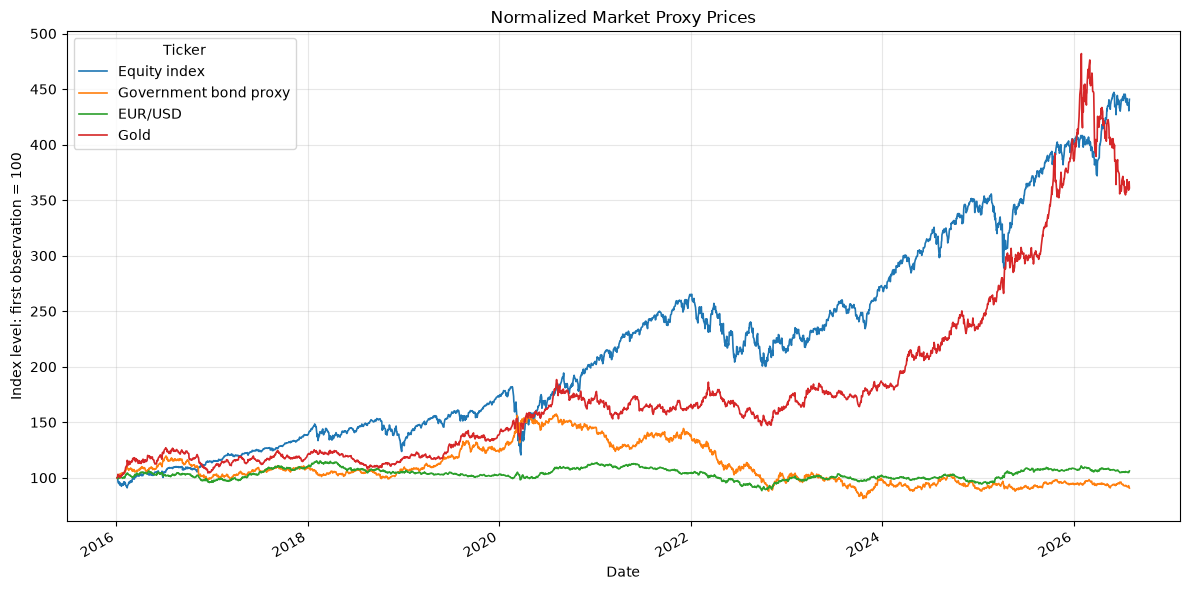

In [87]:
normalized_prices = prices_clean.div(prices_clean.iloc[0]).mul(100)

ax = normalized_prices.plot(
    figsize=(12, 6),
    linewidth=1.2,
    title="Normalized Market Proxy Prices",
)

ax.set_xlabel("Date")
ax.set_ylabel("Index level: first observation = 100")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Daily returns and portfolio P&L

Simple daily returns are calculated from adjusted closing prices.

Each position's daily P&L is approximated as:

\[
P\&L_{i,t}=N_i r_{i,t},
\]

where \(N_i\) is the fixed euro exposure and \(r_{i,t}\) is the daily return
of the corresponding risk factor.

In [88]:
returns = prices_clean.pct_change(fill_method=None).dropna()

assert not returns.empty
assert not returns.isna().any().any()
assert np.isfinite(returns.to_numpy()).all()

print(f"Return observations: {len(returns):,}")
display(returns.head())

Return observations: 2,654


Ticker,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-05,0.001691,-0.004035,-0.002436,0.002819
2016-01-06,-0.012614,0.013476,-0.006978,0.014441
2016-01-07,-0.023992,0.001795,0.002512,0.014140
2016-01-08,-0.010976,0.004478,0.013636,-0.004428
2016-01-11,0.000990,-0.010943,0.001379,-0.008895


In [89]:
notionals = (
    portfolio
    .set_index("risk_factor")["notional_eur"]
    .reindex(returns.columns)
)

if notionals.isna().any():
    raise ValueError(
        "The portfolio names do not match the market-data column names."
    )

position_pnl = returns.mul(notionals, axis="columns")

pnl_data = position_pnl.add_suffix("_pnl_eur")
pnl_data["portfolio_pnl_eur"] = position_pnl.sum(axis=1)

# Verification: total portfolio P&L must equal the sum of position P&Ls.
position_columns = [
    column
    for column in pnl_data.columns
    if column != "portfolio_pnl_eur"
]

assert np.allclose(
    pnl_data[position_columns].sum(axis=1),
    pnl_data["portfolio_pnl_eur"],
)

assert not pnl_data.isna().any().any()

print("Portfolio notionals:")
display(notionals.to_frame("notional_eur"))

print("\nDaily P&L:")
display(pnl_data.head())

Portfolio notionals:


,notional_eur
Ticker,
Equity index,250000
Government bond proxy,300000
EUR/USD,200000
Gold,150000



Daily P&L:


Ticker,Equity index_pnl_eur,Government bond proxy_pnl_eur,EUR/USD_pnl_eur,Gold_pnl_eur,portfolio_pnl_eur
date,,,,,
2016-01-05,422.838435,-1210.471878,-487.227441,422.782949,-852.077936
2016-01-06,-3153.540592,4042.717303,-1395.625824,2166.114353,1659.665240
2016-01-07,-5998.008910,538.490434,502.315779,2120.956410,-2836.246287
2016-01-08,-2744.048204,1343.400326,2727.116186,-664.156214,662.312094
2016-01-11,247.484229,-3283.004797,275.711638,-1334.219964,-4094.028895


In [90]:
pnl_summary = pd.DataFrame(
    {
        "mean_daily_pnl": position_pnl.mean(),
        "daily_pnl_volatility": position_pnl.std(ddof=1),
        "worst_daily_pnl": position_pnl.min(),
        "best_daily_pnl": position_pnl.max(),
    }
)

portfolio_summary = pd.Series(
    {
        "mean_daily_pnl": pnl_data["portfolio_pnl_eur"].mean(),
        "daily_pnl_volatility": pnl_data["portfolio_pnl_eur"].std(ddof=1),
        "worst_daily_pnl": pnl_data["portfolio_pnl_eur"].min(),
        "best_daily_pnl": pnl_data["portfolio_pnl_eur"].max(),
    },
    name="Portfolio",
)

pnl_summary.loc["Portfolio"] = portfolio_summary

display(pnl_summary.round(2))

,mean_daily_pnl,daily_pnl_volatility,worst_daily_pnl,best_daily_pnl
Ticker,,,,
Equity index,155.50,2800.91,-27355.90,26254.86
Government bond proxy,1.94,2786.74,-20005.00,22558.75
EUR/USD,6.68,932.16,-5550.35,5583.89
Gold,80.47,1534.93,-15411.37,9538.08
Portfolio,244.59,4417.58,-35216.13,34761.72


In [91]:
prices_clean.to_csv(
    RAW_DATA_DIR / "market_prices.csv",
    index=True,
)

returns.to_csv(
    PROCESSED_DATA_DIR / "daily_returns.csv",
    index=True,
)

pnl_data.to_csv(
    PROCESSED_DATA_DIR / "daily_pnl.csv",
    index=True,
)

print("Saved files:")
print(RAW_DATA_DIR / "market_prices.csv")
print(PROCESSED_DATA_DIR / "daily_returns.csv")
print(PROCESSED_DATA_DIR / "daily_pnl.csv")

Saved files:
c:\Users\Pranav\Desktop\market-risk-engine\data\raw\market_prices.csv
c:\Users\Pranav\Desktop\market-risk-engine\data\processed\daily_returns.csv
c:\Users\Pranav\Desktop\market-risk-engine\data\processed\daily_pnl.csv


## 4. Historical Simulation VaR and Expected Shortfall

Historical Simulation estimates portfolio risk directly from the empirical
distribution of past daily P&L.

For confidence level \(c\):

\[
VaR_c=-Q_{1-c}(P\&L),
\]

where \(Q_{1-c}\) is the lower-tail P&L quantile.

Expected Shortfall is the average loss on observations at or beyond the
VaR threshold:

\[
ES_c=-E[P\&L\mid P\&L\leq -VaR_c].
\]

VaR identifies a loss threshold, while Expected Shortfall measures the
average severity of losses beyond that threshold.

In [92]:
def calculate_historical_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
    lookback: int | None = None,
) -> dict:
    """
    Calculate Historical Simulation VaR and Expected Shortfall.

    Parameters
    ----------
    pnl_series:
        Daily portfolio P&L, where losses are negative.
    confidence_level:
        Confidence level expressed as a decimal, such as 0.95 or 0.99.
    lookback:
        Number of most recent observations to use. If None, use the
        complete available sample.

    Returns
    -------
    dict
        Risk estimates and sample information.
    """
    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must lie between 0 and 1.")

    clean_pnl = pnl_series.dropna().copy()

    if lookback is not None:
        if lookback <= 0:
            raise ValueError("lookback must be positive.")

        if len(clean_pnl) < lookback:
            raise ValueError(
                f"Requested {lookback} observations, but only "
                f"{len(clean_pnl)} are available."
            )

        clean_pnl = clean_pnl.iloc[-lookback:]

    tail_probability = 1 - confidence_level

    # Lower-tail P&L quantile. This will normally be negative.
    pnl_quantile = clean_pnl.quantile(tail_probability)

    # VaR is reported as a positive loss amount.
    var_eur = -pnl_quantile

    # Tail observations are P&Ls at or below the quantile threshold.
    tail_losses = clean_pnl[clean_pnl <= pnl_quantile]

    if tail_losses.empty:
        raise RuntimeError("No tail observations were identified.")

    # ES is also reported as a positive loss amount.
    expected_shortfall_eur = -tail_losses.mean()

    return {
        "confidence_level": confidence_level,
        "lookback": lookback if lookback is not None else len(clean_pnl),
        "sample_start": clean_pnl.index.min(),
        "sample_end": clean_pnl.index.max(),
        "pnl_quantile_eur": pnl_quantile,
        "var_eur": var_eur,
        "expected_shortfall_eur": expected_shortfall_eur,
        "tail_observations": len(tail_losses),
        "expected_tail_observations": len(clean_pnl) * tail_probability,
    }

In [93]:
portfolio_pnl = pnl_data["portfolio_pnl_eur"]

risk_results = []

lookback_windows = {
    "250-day window": 250,
    "500-day window": 500,
    "Full sample": None,
}

confidence_levels = [0.95, 0.99]

for window_name, lookback in lookback_windows.items():
    for confidence_level in confidence_levels:
        result = calculate_historical_var_es(
            pnl_series=portfolio_pnl,
            confidence_level=confidence_level,
            lookback=lookback,
        )

        result["window_name"] = window_name
        risk_results.append(result)

historical_risk_results = pd.DataFrame(risk_results)

historical_risk_results = historical_risk_results[
    [
        "window_name",
        "confidence_level",
        "lookback",
        "sample_start",
        "sample_end",
        "var_eur",
        "expected_shortfall_eur",
        "tail_observations",
        "expected_tail_observations",
    ]
]

# ES should not be below VaR.
assert (
    historical_risk_results["expected_shortfall_eur"]
    >= historical_risk_results["var_eur"]
).all()

display(
    historical_risk_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "expected_tail_observations": "{:.1f}",
        }
    )
)

,window_name,confidence_level,lookback,sample_start,sample_end,var_eur,expected_shortfall_eur,tail_observations,expected_tail_observations
0,250-day window,95%,250,2025-08-04 00:00:00,2026-07-31 00:00:00,"EUR 7,665.15","EUR 10,767.56",13,12.5
1,250-day window,99%,250,2025-08-04 00:00:00,2026-07-31 00:00:00,"EUR 12,669.90","EUR 14,999.77",3,2.5
2,500-day window,95%,500,2024-08-01 00:00:00,2026-07-31 00:00:00,"EUR 6,937.82","EUR 10,509.52",25,25.0
3,500-day window,99%,500,2024-08-01 00:00:00,2026-07-31 00:00:00,"EUR 13,423.44","EUR 15,189.36",5,5.0
4,Full sample,95%,2654,2016-01-05 00:00:00,2026-07-31 00:00:00,"EUR 6,968.70","EUR 10,196.15",133,132.7
5,Full sample,99%,2654,2016-01-05 00:00:00,2026-07-31 00:00:00,"EUR 11,487.29","EUR 15,748.26",27,26.5


In [94]:
historical_risk_comparison = (
    historical_risk_results
    .pivot(
        index="window_name",
        columns="confidence_level",
        values=["var_eur", "expected_shortfall_eur"],
    )
)

display(
    historical_risk_comparison.style.format("EUR {:,.2f}")
)

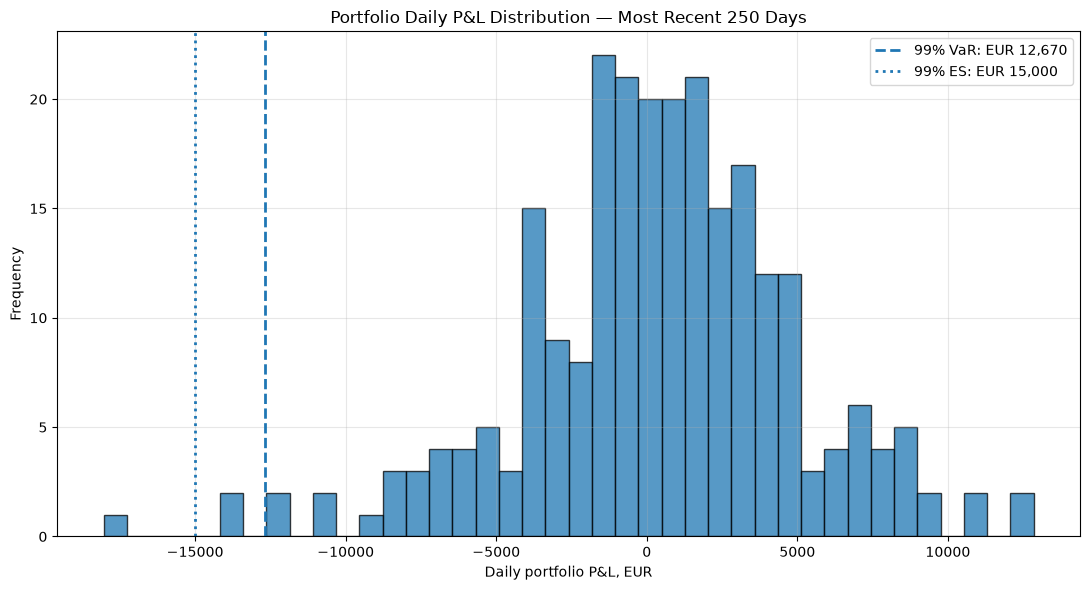

In [95]:
recent_pnl = portfolio_pnl.iloc[-250:]

recent_99_result = calculate_historical_var_es(
    pnl_series=portfolio_pnl,
    confidence_level=0.99,
    lookback=250,
)

recent_var_99 = recent_99_result["var_eur"]
recent_es_99 = recent_99_result["expected_shortfall_eur"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    recent_pnl,
    bins=40,
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(
    -recent_var_99,
    linestyle="--",
    linewidth=2,
    label=f"99% VaR: EUR {recent_var_99:,.0f}",
)

ax.axvline(
    -recent_es_99,
    linestyle=":",
    linewidth=2,
    label=f"99% ES: EUR {recent_es_99:,.0f}",
)

ax.set_title("Portfolio Daily P&L Distribution — Most Recent 250 Days")
ax.set_xlabel("Daily portfolio P&L, EUR")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

historical_risk_results.to_csv(
    TABLES_DIR / "historical_var_es_results.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "historical_pnl_distribution_250_day.png",
    dpi=300,
    bbox_inches="tight",
)

print("Historical VaR and ES outputs saved.")

Historical VaR and ES outputs saved.


### Historical VaR interpretation

The most recent 250-day window produces a 95% Historical VaR of approximately
EUR 7,665 and a 99% Historical VaR of approximately EUR 12,670.

The recent 95% VaR is higher than both the 500-day and full-sample estimates,
suggesting that ordinary recent market volatility has been somewhat elevated.

The 500-day 99% VaR is higher than the corresponding 250-day estimate. This
difference reflects the sensitivity of high-confidence Historical VaR to a
small number of extreme observations. Only three observations enter the 99%
tail of the 250-day sample, compared with five observations in the 500-day
sample and twenty-seven observations in the full sample.

Expected Shortfall exceeds VaR for every window and confidence level, as
required. The full-sample 99% Expected Shortfall is the largest, indicating
that the longer dataset contains several particularly severe tail losses.

A key limitation is that short lookback windows provide very few observations
for estimating the 99% tail, making both VaR and Expected Shortfall unstable.

## 5. Parametric VaR and Expected Shortfall

Parametric VaR assumes that daily portfolio P&L follows a normal distribution.

Under the zero-mean assumption:

\[
VaR_c=z_c\sigma_{P\&L},
\]

where \(z_c\) is the standard-normal critical value and
\(\sigma_{P\&L}\) is the estimated daily P&L volatility.

Normal Expected Shortfall is:

\[
ES_c=
\sigma_{P\&L}
\frac{\phi(z_c)}{1-c},
\]

where \(\phi(z_c)\) is the standard-normal density evaluated at the critical
value.

For short holding periods, market-risk models commonly ignore the expected
daily return because it is small and difficult to estimate reliably.

In [97]:
from scipy.stats import norm


def calculate_parametric_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
    lookback: int | None = None,
    include_mean: bool = False,
) -> dict:
    """
    Calculate normal Parametric VaR and Expected Shortfall.

    Parameters
    ----------
    pnl_series:
        Daily portfolio P&L, with losses represented by negative values.
    confidence_level:
        Confidence level such as 0.95 or 0.99.
    lookback:
        Number of most recent observations used for estimation.
        If None, use the complete sample.
    include_mean:
        Whether to include estimated mean daily P&L.

    Returns
    -------
    dict
        Parametric risk estimates and sample information.
    """
    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must lie between 0 and 1.")

    clean_pnl = pnl_series.dropna().copy()

    if lookback is not None:
        if lookback <= 1:
            raise ValueError("lookback must be greater than one.")

        if len(clean_pnl) < lookback:
            raise ValueError(
                f"Requested {lookback} observations, but only "
                f"{len(clean_pnl)} are available."
            )

        clean_pnl = clean_pnl.iloc[-lookback:]

    mean_pnl = clean_pnl.mean() if include_mean else 0.0
    volatility = clean_pnl.std(ddof=1)

    z_score = norm.ppf(confidence_level)
    density_at_z = norm.pdf(z_score)

    var_eur = z_score * volatility - mean_pnl

    expected_shortfall_eur = (
        volatility
        * density_at_z
        / (1 - confidence_level)
        - mean_pnl
    )

    return {
        "confidence_level": confidence_level,
        "lookback": lookback if lookback is not None else len(clean_pnl),
        "sample_start": clean_pnl.index.min(),
        "sample_end": clean_pnl.index.max(),
        "mean_pnl_used": mean_pnl,
        "pnl_volatility": volatility,
        "z_score": z_score,
        "var_eur": var_eur,
        "expected_shortfall_eur": expected_shortfall_eur,
        "include_mean": include_mean,
    }

In [98]:
parametric_results = []

for window_name, lookback in lookback_windows.items():
    for confidence_level in confidence_levels:
        result = calculate_parametric_var_es(
            pnl_series=portfolio_pnl,
            confidence_level=confidence_level,
            lookback=lookback,
            include_mean=False,
        )

        result["window_name"] = window_name
        parametric_results.append(result)

parametric_risk_results = pd.DataFrame(parametric_results)

parametric_risk_results = parametric_risk_results[
    [
        "window_name",
        "confidence_level",
        "lookback",
        "sample_start",
        "sample_end",
        "mean_pnl_used",
        "pnl_volatility",
        "z_score",
        "var_eur",
        "expected_shortfall_eur",
    ]
]

assert (
    parametric_risk_results["expected_shortfall_eur"]
    >= parametric_risk_results["var_eur"]
).all()

display(
    parametric_risk_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "mean_pnl_used": "EUR {:,.2f}",
            "pnl_volatility": "EUR {:,.2f}",
            "z_score": "{:.4f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,window_name,confidence_level,lookback,sample_start,sample_end,mean_pnl_used,pnl_volatility,z_score,var_eur,expected_shortfall_eur
0,250-day window,95%,250,2025-08-04 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,598.94",1.6449,"EUR 7,564.59","EUR 9,486.30"
1,250-day window,99%,250,2025-08-04 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,598.94",2.3263,"EUR 10,698.74","EUR 12,257.16"
2,500-day window,95%,500,2024-08-01 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,687.57",1.6449,"EUR 7,710.37","EUR 9,669.11"
3,500-day window,99%,500,2024-08-01 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,687.57",2.3263,"EUR 10,904.92","EUR 12,493.38"
4,Full sample,95%,2654,2016-01-05 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,417.58",1.6449,"EUR 7,266.27","EUR 9,112.20"
5,Full sample,99%,2654,2016-01-05 00:00:00,2026-07-31 00:00:00,EUR 0.00,"EUR 4,417.58",2.3263,"EUR 10,276.83","EUR 11,773.80"


In [99]:
historical_comparison = historical_risk_results[
    [
        "window_name",
        "confidence_level",
        "var_eur",
        "expected_shortfall_eur",
    ]
].rename(
    columns={
        "var_eur": "historical_var_eur",
        "expected_shortfall_eur": "historical_es_eur",
    }
)

parametric_comparison = parametric_risk_results[
    [
        "window_name",
        "confidence_level",
        "var_eur",
        "expected_shortfall_eur",
    ]
].rename(
    columns={
        "var_eur": "parametric_var_eur",
        "expected_shortfall_eur": "parametric_es_eur",
    }
)

var_method_comparison = historical_comparison.merge(
    parametric_comparison,
    on=["window_name", "confidence_level"],
    how="inner",
)

var_method_comparison["var_difference_eur"] = (
    var_method_comparison["parametric_var_eur"]
    - var_method_comparison["historical_var_eur"]
)

var_method_comparison["es_difference_eur"] = (
    var_method_comparison["parametric_es_eur"]
    - var_method_comparison["historical_es_eur"]
)

display(
    var_method_comparison.style.format(
        {
            "confidence_level": "{:.0%}",
            "historical_var_eur": "EUR {:,.2f}",
            "historical_es_eur": "EUR {:,.2f}",
            "parametric_var_eur": "EUR {:,.2f}",
            "parametric_es_eur": "EUR {:,.2f}",
            "var_difference_eur": "EUR {:,.2f}",
            "es_difference_eur": "EUR {:,.2f}",
        }
    )
)

,window_name,confidence_level,historical_var_eur,historical_es_eur,parametric_var_eur,parametric_es_eur,var_difference_eur,es_difference_eur
0,250-day window,95%,"EUR 7,665.15","EUR 10,767.56","EUR 7,564.59","EUR 9,486.30",EUR -100.57,"EUR -1,281.26"
1,250-day window,99%,"EUR 12,669.90","EUR 14,999.77","EUR 10,698.74","EUR 12,257.16","EUR -1,971.16","EUR -2,742.61"
2,500-day window,95%,"EUR 6,937.82","EUR 10,509.52","EUR 7,710.37","EUR 9,669.11",EUR 772.55,EUR -840.41
3,500-day window,99%,"EUR 13,423.44","EUR 15,189.36","EUR 10,904.92","EUR 12,493.38","EUR -2,518.52","EUR -2,695.98"
4,Full sample,95%,"EUR 6,968.70","EUR 10,196.15","EUR 7,266.27","EUR 9,112.20",EUR 297.57,"EUR -1,083.95"
5,Full sample,99%,"EUR 11,487.29","EUR 15,748.26","EUR 10,276.83","EUR 11,773.80","EUR -1,210.46","EUR -3,974.46"


In [100]:
var_method_comparison["parametric_vs_historical_var_pct"] = (
    var_method_comparison["parametric_var_eur"]
    / var_method_comparison["historical_var_eur"]
    - 1
)

var_method_comparison["parametric_vs_historical_es_pct"] = (
    var_method_comparison["parametric_es_eur"]
    / var_method_comparison["historical_es_eur"]
    - 1
)

display(
    var_method_comparison[
        [
            "window_name",
            "confidence_level",
            "parametric_vs_historical_var_pct",
            "parametric_vs_historical_es_pct",
        ]
    ].style.format(
        {
            "confidence_level": "{:.0%}",
            "parametric_vs_historical_var_pct": "{:+.2%}",
            "parametric_vs_historical_es_pct": "{:+.2%}",
        }
    )
)

,window_name,confidence_level,parametric_vs_historical_var_pct,parametric_vs_historical_es_pct
0,250-day window,95%,-1.31%,-11.90%
1,250-day window,99%,-15.56%,-18.28%
2,500-day window,95%,+11.14%,-8.00%
3,500-day window,99%,-18.76%,-17.75%
4,Full sample,95%,+4.27%,-10.63%
5,Full sample,99%,-10.54%,-25.24%


In [101]:
parametric_risk_results.to_csv(
    TABLES_DIR / "parametric_var_es_results.csv",
    index=False,
)

var_method_comparison.to_csv(
    TABLES_DIR / "var_method_comparison.csv",
    index=False,
)

print("Parametric VaR and comparison tables saved.")

Parametric VaR and comparison tables saved.


### Parametric versus Historical Simulation interpretation

Parametric and Historical VaR are relatively similar at the 95% confidence
level. For the most recent 250-day window, Parametric VaR is approximately
EUR 7,565 compared with Historical VaR of approximately EUR 7,665.

The difference becomes materially larger at the 99% confidence level.
The recent Parametric VaR is approximately EUR 10,699, around EUR 1,971
below the Historical VaR estimate. Parametric Expected Shortfall is also
approximately EUR 2,743 below Historical Expected Shortfall.

The normal model therefore appears to understate the severity of empirical
tail losses. This is particularly visible at the 99% confidence level, where
the result depends more heavily on extreme observations.

The estimated daily mean is excluded from the Parametric VaR calculation.
For a one-day risk horizon, expected return is small relative to daily
volatility and is difficult to estimate reliably.

## 6. Rolling VaR backtesting

A rolling backtest evaluates whether the VaR model generated an appropriate
number of exceptions through time.

For each date \(t\), the model uses the preceding 250 observations to estimate
a one-day 99% VaR forecast. An exception occurs when realised portfolio P&L
falls below the negative VaR boundary:

\[
\text{Exception}_t =
\begin{cases}
1, & P\&L_t < -VaR_t,\\
0, & \text{otherwise}.
\end{cases}
\]

The P&L series is shifted before applying the rolling window to prevent
look-ahead bias.

In [102]:
BACKTEST_WINDOW = 250
BACKTEST_CONFIDENCE = 0.99
TAIL_PROBABILITY = 1 - BACKTEST_CONFIDENCE

lagged_pnl = portfolio_pnl.shift(1)

rolling_historical_var = (
    -lagged_pnl
    .rolling(window=BACKTEST_WINDOW, min_periods=BACKTEST_WINDOW)
    .quantile(TAIL_PROBABILITY)
)

rolling_parametric_volatility = (
    lagged_pnl
    .rolling(window=BACKTEST_WINDOW, min_periods=BACKTEST_WINDOW)
    .std(ddof=1)
)

rolling_parametric_var = (
    norm.ppf(BACKTEST_CONFIDENCE)
    * rolling_parametric_volatility
)

backtest_results = pd.DataFrame(
    {
        "actual_pnl_eur": portfolio_pnl,
        "historical_var_eur": rolling_historical_var,
        "parametric_var_eur": rolling_parametric_var,
    }
).dropna()

backtest_results["historical_exception"] = (
    backtest_results["actual_pnl_eur"]
    < -backtest_results["historical_var_eur"]
)

backtest_results["parametric_exception"] = (
    backtest_results["actual_pnl_eur"]
    < -backtest_results["parametric_var_eur"]
)

assert len(backtest_results) == len(portfolio_pnl) - BACKTEST_WINDOW
assert (backtest_results["historical_var_eur"] > 0).all()
assert (backtest_results["parametric_var_eur"] > 0).all()

print(
    f"Backtesting sample: "
    f"{backtest_results.index.min().date()} to "
    f"{backtest_results.index.max().date()}"
)

print(f"Backtesting observations: {len(backtest_results):,}")

display(backtest_results.head())

Backtesting sample: 2016-12-30 to 2026-07-31
Backtesting observations: 2,404


,actual_pnl_eur,historical_var_eur,parametric_var_eur,historical_exception,parametric_exception
date,,,,,
2016-12-30,1654.611656,9212.821078,7807.960270,False,False
2017-01-03,2194.106621,9212.821078,7809.522778,False,False
2017-01-04,2403.266442,9212.821078,7812.115598,False,False
2017-01-05,8378.931018,9212.821078,7806.115735,False,False
2017-01-06,-965.687886,9212.821078,7897.957294,False,False


In [103]:
number_of_forecasts = len(backtest_results)
expected_exceptions = number_of_forecasts * TAIL_PROBABILITY

exception_summary = pd.DataFrame(
    {
        "model": [
            "Historical Simulation",
            "Parametric Normal",
        ],
        "observations": [
            number_of_forecasts,
            number_of_forecasts,
        ],
        "expected_exceptions": [
            expected_exceptions,
            expected_exceptions,
        ],
        "actual_exceptions": [
            backtest_results["historical_exception"].sum(),
            backtest_results["parametric_exception"].sum(),
        ],
    }
)

exception_summary["expected_exception_rate"] = TAIL_PROBABILITY

exception_summary["actual_exception_rate"] = (
    exception_summary["actual_exceptions"]
    / exception_summary["observations"]
)

exception_summary["exception_difference"] = (
    exception_summary["actual_exceptions"]
    - exception_summary["expected_exceptions"]
)

display(
    exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,Historical Simulation,2404,24.04,41,1.00%,1.71%,+16.96
1,Parametric Normal,2404,24.04,46,1.00%,1.91%,+21.96


### 6.1 Kupiec unconditional-coverage test

The Kupiec test evaluates whether the observed proportion of VaR exceptions
is statistically consistent with the model's expected exception probability.

The null hypothesis is:

\[
H_0:\hat{p}=p,
\]

where \(p=1-c\) is the expected exception probability and
\(\hat{p}=x/T\) is the observed exception rate.

A low p-value indicates that the model's observed exception frequency is
inconsistent with its stated confidence level.

In [104]:
from scipy.special import xlogy
from scipy.stats import chi2


def kupiec_unconditional_coverage_test(
    exceptions: pd.Series,
    confidence_level: float,
) -> dict:
    """
    Perform the Kupiec unconditional-coverage test.

    Parameters
    ----------
    exceptions:
        Boolean or binary series, where one indicates a VaR exception.
    confidence_level:
        VaR confidence level, such as 0.99.

    Returns
    -------
    dict
        Exception counts, likelihood-ratio statistic and p-value.
    """
    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must lie between 0 and 1.")

    exception_values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
    )

    observations = len(exception_values)

    if observations == 0:
        raise ValueError("The exception series is empty.")

    exceptions_count = int(exception_values.sum())
    expected_probability = 1 - confidence_level
    observed_probability = exceptions_count / observations

    null_log_likelihood = (
        xlogy(exceptions_count, expected_probability)
        + xlogy(
            observations - exceptions_count,
            1 - expected_probability,
        )
    )

    alternative_log_likelihood = (
        xlogy(exceptions_count, observed_probability)
        + xlogy(
            observations - exceptions_count,
            1 - observed_probability,
        )
    )

    likelihood_ratio = -2 * (
        null_log_likelihood - alternative_log_likelihood
    )

    p_value = chi2.sf(likelihood_ratio, df=1)

    return {
        "observations": observations,
        "expected_probability": expected_probability,
        "observed_probability": observed_probability,
        "expected_exceptions": observations * expected_probability,
        "actual_exceptions": exceptions_count,
        "kupiec_lr_statistic": likelihood_ratio,
        "kupiec_p_value": p_value,
        "reject_at_5_percent": p_value < 0.05,
    }

In [105]:
kupiec_results = []

model_exception_columns = {
    "Historical Simulation": "historical_exception",
    "Parametric Normal": "parametric_exception",
}

for model_name, exception_column in model_exception_columns.items():
    result = kupiec_unconditional_coverage_test(
        exceptions=backtest_results[exception_column],
        confidence_level=BACKTEST_CONFIDENCE,
    )

    result["model"] = model_name
    kupiec_results.append(result)

kupiec_results = pd.DataFrame(kupiec_results)[
    [
        "model",
        "observations",
        "expected_exceptions",
        "actual_exceptions",
        "expected_probability",
        "observed_probability",
        "kupiec_lr_statistic",
        "kupiec_p_value",
        "reject_at_5_percent",
    ]
]

display(
    kupiec_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_probability": "{:.2%}",
            "observed_probability": "{:.2%}",
            "kupiec_lr_statistic": "{:.4f}",
            "kupiec_p_value": "{:.4f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_probability,observed_probability,kupiec_lr_statistic,kupiec_p_value,reject_at_5_percent
0,Historical Simulation,2404,24.04,41,1.00%,1.71%,9.9771,0.0016,True
1,Parametric Normal,2404,24.04,46,1.00%,1.91%,15.9841,0.0001,True


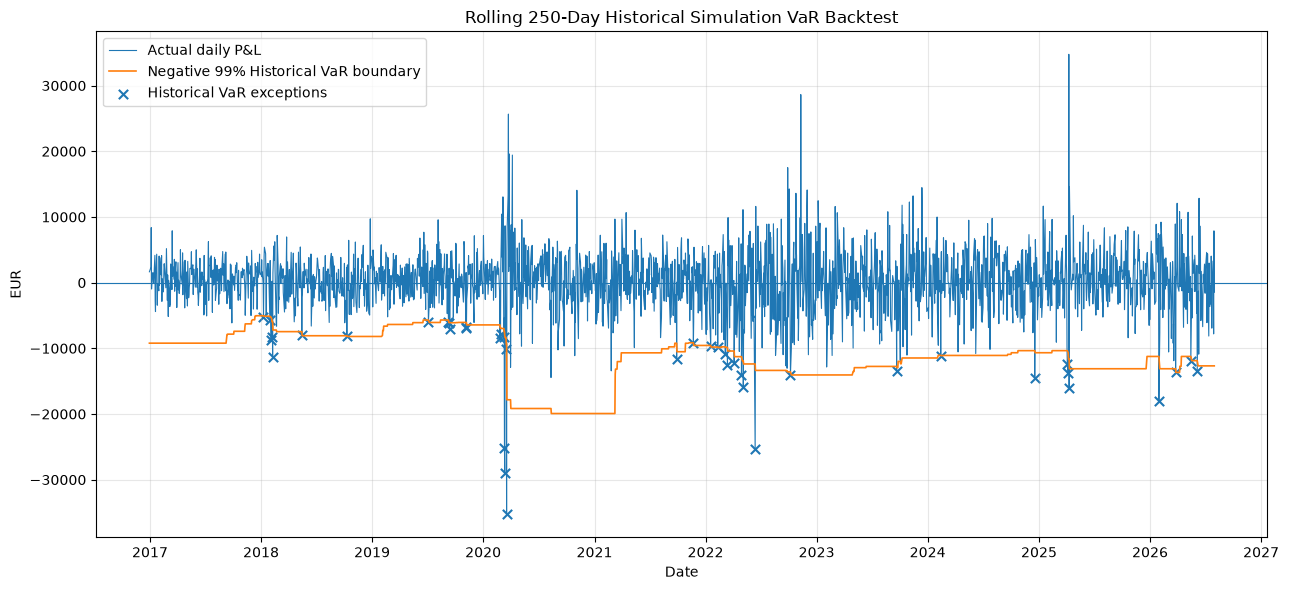

In [106]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    backtest_results.index,
    backtest_results["actual_pnl_eur"],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    backtest_results.index,
    -backtest_results["historical_var_eur"],
    linewidth=1.2,
    label="Negative 99% Historical VaR boundary",
)

historical_exception_dates = backtest_results[
    backtest_results["historical_exception"]
]

ax.scatter(
    historical_exception_dates.index,
    historical_exception_dates["actual_pnl_eur"],
    marker="x",
    s=45,
    label="Historical VaR exceptions",
)

ax.axhline(0, linewidth=0.8)

ax.set_title(
    "Rolling 250-Day Historical Simulation VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
backtest_results.to_csv(
    TABLES_DIR / "rolling_var_backtest.csv",
    index=True,
)

exception_summary.to_csv(
    TABLES_DIR / "var_exception_summary.csv",
    index=False,
)

kupiec_results.to_csv(
    TABLES_DIR / "kupiec_test_results.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "historical_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("Rolling backtesting outputs saved.")

Rolling backtesting outputs saved.


### Rolling VaR and Kupiec-test interpretation

The 2,404-day backtesting sample implies approximately 24 expected exceptions
for a correctly calibrated 99% VaR model.

The Historical Simulation model produces 41 exceptions, corresponding to an
observed exception rate of 1.71%. The Kupiec test gives a p-value of 0.0016,
so the null hypothesis of correct unconditional coverage is rejected at the
5% significance level.

The Parametric Normal model produces 46 exceptions, corresponding to an
observed exception rate of 1.91%. Its Kupiec p-value is 0.0001, so correct
unconditional coverage is also rejected.

Both models therefore underestimate risk over the backtesting sample. The
Parametric Normal model performs worse based on its higher exception count
and larger likelihood-ratio statistic. This is consistent with the earlier
finding that the normal model understates empirical tail risk.

The Kupiec test evaluates exception frequency only. It does not assess whether
exceptions occur independently or cluster during stressed periods.

### 6.2 Christoffersen independence test

The Christoffersen independence test evaluates whether VaR exceptions occur
independently through time.

The exception sequence is divided into four transition types:

- \(n_{00}\): no exception followed by no exception
- \(n_{01}\): no exception followed by an exception
- \(n_{10}\): exception followed by no exception
- \(n_{11}\): exception followed by another exception

The null hypothesis is that the probability of an exception does not depend
on whether the preceding day was also an exception.

A low p-value indicates that exceptions are clustered and therefore not
independent.

In [108]:
def christoffersen_independence_test(
    exceptions: pd.Series,
) -> dict:
    """
    Perform the Christoffersen independence test for VaR exceptions.

    Parameters
    ----------
    exceptions:
        Boolean or binary exception series.

    Returns
    -------
    dict
        Transition counts, likelihood-ratio statistic and p-value.
    """
    exception_values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
        .to_numpy()
    )

    if len(exception_values) < 2:
        raise ValueError(
            "At least two exception observations are required."
        )

    previous = exception_values[:-1]
    current = exception_values[1:]

    n00 = int(((previous == 0) & (current == 0)).sum())
    n01 = int(((previous == 0) & (current == 1)).sum())
    n10 = int(((previous == 1) & (current == 0)).sum())
    n11 = int(((previous == 1) & (current == 1)).sum())

    total_transitions = n00 + n01 + n10 + n11
    total_exceptions = n01 + n11

    unconditional_probability = (
        total_exceptions / total_transitions
    )

    probability_after_no_exception = (
        n01 / (n00 + n01)
        if (n00 + n01) > 0
        else 0.0
    )

    probability_after_exception = (
        n11 / (n10 + n11)
        if (n10 + n11) > 0
        else 0.0
    )

    null_log_likelihood = (
        xlogy(n00 + n10, 1 - unconditional_probability)
        + xlogy(n01 + n11, unconditional_probability)
    )

    alternative_log_likelihood = (
        xlogy(n00, 1 - probability_after_no_exception)
        + xlogy(n01, probability_after_no_exception)
        + xlogy(n10, 1 - probability_after_exception)
        + xlogy(n11, probability_after_exception)
    )

    likelihood_ratio = -2 * (
        null_log_likelihood - alternative_log_likelihood
    )

    p_value = chi2.sf(likelihood_ratio, df=1)

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "probability_after_no_exception": (
            probability_after_no_exception
        ),
        "probability_after_exception": (
            probability_after_exception
        ),
        "christoffersen_independence_lr": likelihood_ratio,
        "christoffersen_independence_p_value": p_value,
        "reject_independence_at_5_percent": p_value < 0.05,
    }

In [109]:
independence_results = []

for model_name, exception_column in model_exception_columns.items():
    result = christoffersen_independence_test(
        exceptions=backtest_results[exception_column]
    )

    result["model"] = model_name
    independence_results.append(result)

independence_results = pd.DataFrame(independence_results)[
    [
        "model",
        "n00",
        "n01",
        "n10",
        "n11",
        "probability_after_no_exception",
        "probability_after_exception",
        "christoffersen_independence_lr",
        "christoffersen_independence_p_value",
        "reject_independence_at_5_percent",
    ]
]

display(
    independence_results.style.format(
        {
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "christoffersen_independence_lr": "{:.4f}",
            "christoffersen_independence_p_value": "{:.4f}",
        }
    )
)

,model,n00,n01,n10,n11,probability_after_no_exception,probability_after_exception,christoffersen_independence_lr,christoffersen_independence_p_value,reject_independence_at_5_percent
0,Historical Simulation,2325,37,37,4,1.57%,9.76%,7.9087,0.0049,True
1,Parametric Normal,2316,41,41,5,1.74%,10.87%,9.9110,0.0016,True


In [110]:
conditional_coverage_results = kupiec_results[
    [
        "model",
        "kupiec_lr_statistic",
    ]
].merge(
    independence_results[
        [
            "model",
            "christoffersen_independence_lr",
        ]
    ],
    on="model",
    how="inner",
)

conditional_coverage_results[
    "conditional_coverage_lr"
] = (
    conditional_coverage_results["kupiec_lr_statistic"]
    + conditional_coverage_results[
        "christoffersen_independence_lr"
    ]
)

conditional_coverage_results[
    "conditional_coverage_p_value"
] = chi2.sf(
    conditional_coverage_results[
        "conditional_coverage_lr"
    ],
    df=2,
)

conditional_coverage_results[
    "reject_conditional_coverage_at_5_percent"
] = (
    conditional_coverage_results[
        "conditional_coverage_p_value"
    ]
    < 0.05
)

display(
    conditional_coverage_results.style.format(
        {
            "kupiec_lr_statistic": "{:.4f}",
            "christoffersen_independence_lr": "{:.4f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.4f}",
        }
    )
)

,model,kupiec_lr_statistic,christoffersen_independence_lr,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Historical Simulation,9.9771,7.9087,17.8858,0.0001,True
1,Parametric Normal,15.9841,9.9110,25.8951,0.0000,True


In [111]:
independence_results.to_csv(
    TABLES_DIR / "christoffersen_independence_results.csv",
    index=False,
)

conditional_coverage_results.to_csv(
    TABLES_DIR / "conditional_coverage_results.csv",
    index=False,
)

print("Christoffersen backtesting outputs saved.")

Christoffersen backtesting outputs saved.


### Christoffersen-test interpretation

Both VaR models exhibit statistically significant exception clustering.

For Historical Simulation, the probability of an exception following a
non-exception is approximately 1.57%, while the probability of another
exception immediately following an exception rises to approximately 9.76%.
The Christoffersen independence-test p-value is 0.0049, so exception
independence is rejected.

For the Parametric Normal model, the corresponding probabilities are 1.74%
and 10.87%. Its independence-test p-value is 0.0016, so independence is also
rejected.

The conditional-coverage test combines exception-frequency calibration with
exception independence. Conditional coverage is rejected for both models.
The Parametric Normal model performs worse based on its higher exception
frequency and larger conditional-coverage statistic.

The findings indicate that the models do not adapt sufficiently to stressed
volatility regimes. However, the statistical tests alone do not identify the
precise cause of the model failures.

## 7. Historical stress testing

Historical stress testing evaluates the portfolio under the most adverse
market movements observed in the available dataset.

The analysis identifies the worst cumulative portfolio P&L over one-day,
five-day and twenty-day windows. Position-level P&L is summed over each
window to identify the principal drivers of loss.

Because the initial portfolio uses fixed linear exposures, multi-day P&L is
calculated as the sum of daily position P&Ls rather than through full
portfolio revaluation.

In [112]:
def identify_worst_historical_window(
    position_pnl_data: pd.DataFrame,
    window: int,
) -> tuple[dict, pd.DataFrame]:
    """
    Identify the worst rolling cumulative P&L window.

    Parameters
    ----------
    position_pnl_data:
        DataFrame containing daily P&L by risk factor.
    window:
        Number of trading days in the stress window.

    Returns
    -------
    tuple
        Summary dictionary and risk-factor contribution table.
    """
    if window <= 0:
        raise ValueError("window must be a positive integer.")

    if len(position_pnl_data) < window:
        raise ValueError(
            f"Window of {window} days exceeds the available sample."
        )

    portfolio_daily_pnl = position_pnl_data.sum(axis=1)

    rolling_portfolio_pnl = (
        portfolio_daily_pnl
        .rolling(window=window, min_periods=window)
        .sum()
    )

    worst_end_date = rolling_portfolio_pnl.idxmin()
    worst_end_position = position_pnl_data.index.get_loc(
        worst_end_date
    )
    worst_start_position = worst_end_position - window + 1

    stress_window_data = position_pnl_data.iloc[
        worst_start_position:worst_end_position + 1
    ]

    contributions = stress_window_data.sum()
    cumulative_portfolio_pnl = contributions.sum()
    portfolio_loss = -cumulative_portfolio_pnl

    main_loss_contributor = contributions.idxmin()

    contribution_table = pd.DataFrame(
        {
            "risk_factor": contributions.index,
            "cumulative_pnl_eur": contributions.values,
        }
    )

    contribution_table["loss_contribution_eur"] = (
        -contribution_table["cumulative_pnl_eur"]
    )

    contribution_table["share_of_total_loss"] = (
        contribution_table["loss_contribution_eur"]
        / portfolio_loss
    )

    contribution_table["window_days"] = window
    contribution_table["window_start"] = (
        stress_window_data.index.min()
    )
    contribution_table["window_end"] = (
        stress_window_data.index.max()
    )

    summary = {
        "window_days": window,
        "window_start": stress_window_data.index.min(),
        "window_end": stress_window_data.index.max(),
        "cumulative_portfolio_pnl_eur": cumulative_portfolio_pnl,
        "portfolio_loss_eur": portfolio_loss,
        "main_loss_contributor": main_loss_contributor,
        "main_contributor_pnl_eur": contributions[
            main_loss_contributor
        ],
    }

    return summary, contribution_table

In [113]:
stress_summaries = []
stress_contribution_tables = []

for stress_window in [1, 5, 20]:
    summary, contributions = identify_worst_historical_window(
        position_pnl_data=position_pnl,
        window=stress_window,
    )

    stress_summaries.append(summary)
    stress_contribution_tables.append(contributions)

stress_summary = pd.DataFrame(stress_summaries)

stress_contributions = pd.concat(
    stress_contribution_tables,
    ignore_index=True,
)

display(
    stress_summary.style.format(
        {
            "cumulative_portfolio_pnl_eur": "EUR {:,.2f}",
            "portfolio_loss_eur": "EUR {:,.2f}",
            "main_contributor_pnl_eur": "EUR {:,.2f}",
        }
    )
)

,window_days,window_start,window_end,cumulative_portfolio_pnl_eur,portfolio_loss_eur,main_loss_contributor,main_contributor_pnl_eur
0,1,2020-03-18 00:00:00,2020-03-18 00:00:00,"EUR -35,216.13","EUR 35,216.13",Government bond proxy,"EUR -16,923.71"
1,5,2020-03-12 00:00:00,2020-03-18 00:00:00,"EUR -70,083.26","EUR 70,083.26",Equity index,"EUR -29,063.79"
2,20,2020-02-20 00:00:00,2020-03-18 00:00:00,"EUR -84,178.95","EUR 84,178.95",Equity index,"EUR -78,771.15"


In [114]:
display(
    stress_contributions.style.format(
        {
            "cumulative_pnl_eur": "EUR {:,.2f}",
            "loss_contribution_eur": "EUR {:,.2f}",
            "share_of_total_loss": "{:+.2%}",
        }
    )
)

,risk_factor,cumulative_pnl_eur,loss_contribution_eur,share_of_total_loss,window_days,window_start,window_end
0,Equity index,"EUR -12,658.20","EUR 12,658.20",+35.94%,1,2020-03-18 00:00:00,2020-03-18 00:00:00
1,Government bond proxy,"EUR -16,923.71","EUR 16,923.71",+48.06%,1,2020-03-18 00:00:00,2020-03-18 00:00:00
2,EUR/USD,"EUR -2,645.92","EUR 2,645.92",+7.51%,1,2020-03-18 00:00:00,2020-03-18 00:00:00
3,Gold,"EUR -2,988.30","EUR 2,988.30",+8.49%,1,2020-03-18 00:00:00,2020-03-18 00:00:00
4,Equity index,"EUR -29,063.79","EUR 29,063.79",+41.47%,5,2020-03-12 00:00:00,2020-03-18 00:00:00
5,Government bond proxy,"EUR -22,420.91","EUR 22,420.91",+31.99%,5,2020-03-12 00:00:00,2020-03-18 00:00:00
6,EUR/USD,"EUR -5,365.98","EUR 5,365.98",+7.66%,5,2020-03-12 00:00:00,2020-03-18 00:00:00
7,Gold,"EUR -13,232.57","EUR 13,232.57",+18.88%,5,2020-03-12 00:00:00,2020-03-18 00:00:00
8,Equity index,"EUR -78,771.15","EUR 78,771.15",+93.58%,20,2020-02-20 00:00:00,2020-03-18 00:00:00
9,Government bond proxy,"EUR 1,307.87","EUR -1,307.87",-1.55%,20,2020-02-20 00:00:00,2020-03-18 00:00:00


In [115]:
for stress_window in [1, 5, 20]:
    summary_row = stress_summary[
        stress_summary["window_days"] == stress_window
    ].iloc[0]

    contribution_total = stress_contributions.loc[
        stress_contributions["window_days"] == stress_window,
        "cumulative_pnl_eur",
    ].sum()

    assert np.isclose(
        contribution_total,
        summary_row["cumulative_portfolio_pnl_eur"],
    )

    assert summary_row["portfolio_loss_eur"] >= 0

print("Historical stress-test calculations verified.")

Historical stress-test calculations verified.


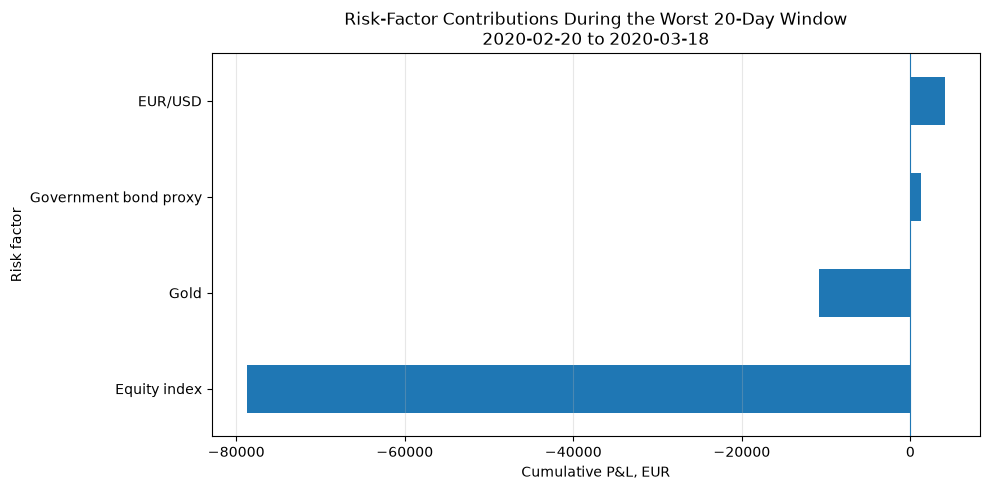

In [116]:
worst_20_day_contributions = (
    stress_contributions[
        stress_contributions["window_days"] == 20
    ]
    .set_index("risk_factor")["cumulative_pnl_eur"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))

worst_20_day_contributions.plot(
    kind="barh",
    ax=ax,
)

worst_20_summary = stress_summary[
    stress_summary["window_days"] == 20
].iloc[0]

ax.set_title(
    "Risk-Factor Contributions During the Worst 20-Day Window\n"
    f"{worst_20_summary['window_start'].date()} to "
    f"{worst_20_summary['window_end'].date()}"
)
ax.set_xlabel("Cumulative P&L, EUR")
ax.set_ylabel("Risk factor")
ax.axvline(0, linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [117]:
stress_summary.to_csv(
    TABLES_DIR / "historical_stress_summary.csv",
    index=False,
)

stress_contributions.to_csv(
    TABLES_DIR / "historical_stress_contributions.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "worst_20_day_stress_contributions.png",
    dpi=300,
    bbox_inches="tight",
)

print("Historical stress-testing outputs saved.")

Historical stress-testing outputs saved.


### Historical stress-test interpretation

The portfolio's worst one-day, five-day and twenty-day historical stress
windows all end on 18 March 2020, showing that the most severe losses were
concentrated within the same stressed market period.

The worst one-day portfolio loss is approximately EUR 35,216. The government
bond proxy is the largest individual loss contributor on that date, with a
loss of approximately EUR 16,924.

The worst five-day cumulative loss is approximately EUR 70,083. Over this
longer window, the equity index becomes the main loss contributor, generating
a cumulative loss of approximately EUR 29,064.

The worst twenty-day cumulative portfolio loss is approximately EUR 84,179.
The equity exposure contributes approximately EUR 78,771 of this loss,
indicating that sustained equity-market weakness is the portfolio's principal
longer-horizon historical vulnerability.

The stress losses cannot be directly compared with one-day VaR without
recognising the difference in horizon. The stress analysis also uses fixed
linear exposures and sums daily P&L rather than fully repricing and compounding
the portfolio through each period.

In [118]:
worst_20_day_table = (
    stress_contributions[
        stress_contributions["window_days"] == 20
    ][
        [
            "risk_factor",
            "cumulative_pnl_eur",
            "loss_contribution_eur",
            "share_of_total_loss",
            "window_start",
            "window_end",
        ]
    ]
    .sort_values("cumulative_pnl_eur")
    .reset_index(drop=True)
)

display(
    worst_20_day_table.style.format(
        {
            "cumulative_pnl_eur": "EUR {:,.2f}",
            "loss_contribution_eur": "EUR {:,.2f}",
            "share_of_total_loss": "{:+.2%}",
        }
    )
)

,risk_factor,cumulative_pnl_eur,loss_contribution_eur,share_of_total_loss,window_start,window_end
0,Equity index,"EUR -78,771.15","EUR 78,771.15",+93.58%,2020-02-20 00:00:00,2020-03-18 00:00:00
1,Gold,"EUR -10,835.84","EUR 10,835.84",+12.87%,2020-02-20 00:00:00,2020-03-18 00:00:00
2,Government bond proxy,"EUR 1,307.87","EUR -1,307.87",-1.55%,2020-02-20 00:00:00,2020-03-18 00:00:00
3,EUR/USD,"EUR 4,120.17","EUR -4,120.17",-4.89%,2020-02-20 00:00:00,2020-03-18 00:00:00


### Worst twenty-day stress contributions

During the worst twenty-day historical window, from 20 February 2020 to
18 March 2020, the portfolio lost approximately EUR 84,179.

The equity exposure generated a loss of approximately EUR 78,771 and accounted
for 93.58% of the net portfolio loss. Gold generated a further loss of
approximately EUR 10,836, equivalent to 12.87% of the net loss.

The government bond and EUR/USD positions partially offset the stress event.
They generated gains of approximately EUR 1,308 and EUR 4,120 respectively.

The gross loss contributions from equity and gold exceed 100% of the net
portfolio loss because gains on the bond and foreign-exchange positions
provided diversification benefits during the period.

## 8. Overall findings

This initial market-risk engine analyses a EUR 900,000 multi-asset portfolio
containing equity, government-bond, foreign-exchange and gold exposures.

### Static risk estimates

Using the most recent 250 observations:

- 95% Historical VaR is approximately EUR 7,665.
- 99% Historical VaR is approximately EUR 12,670.
- 99% Historical Expected Shortfall is approximately EUR 15,000.
- 99% Parametric Normal VaR is approximately EUR 10,699.
- 99% Parametric Normal Expected Shortfall is approximately EUR 12,257.

The normal model produces lower tail-risk estimates than Historical
Simulation. The difference is especially material at the 99% confidence
level, indicating that the normal assumption does not fully capture the
portfolio's empirical tail losses.

### Backtesting

Across 2,404 rolling one-day forecasts, approximately 24 exceptions would be
expected from a correctly calibrated 99% VaR model.

- Historical Simulation produces 41 exceptions.
- Parametric Normal VaR produces 46 exceptions.

The Kupiec test rejects correct unconditional coverage for both models.

The Christoffersen independence test also rejects exception independence.
Following a Historical Simulation exception, the probability of another
exception rises to approximately 9.76%. For Parametric Normal VaR, it rises
to approximately 10.87%.

Both models consequently fail the combined conditional-coverage test. The
results indicate that the models underestimate risk and adapt insufficiently
to changing volatility regimes.

### Historical stress testing

The worst historical stress windows all end on 18 March 2020:

- Worst one-day loss: approximately EUR 35,216.
- Worst five-day loss: approximately EUR 70,083.
- Worst twenty-day loss: approximately EUR 84,179.

Equity is the principal driver of the worst twenty-day loss, accounting for
approximately 93.58% of the net loss. Government bonds and EUR/USD provide
partial offsets.

### Initial model limitations

- Portfolio positions are represented using fixed linear exposures.
- Bonds are represented by an ETF rather than direct yield-curve sensitivities.
- Options, swaps and nonlinear payoffs are not yet included.
- USD-denominated ETF returns are treated as euro P&L factors without separate
  currency translation.
- Historical Simulation gives equal weight to every observation in the window.
- Parametric VaR assumes normally distributed P&L.
- The rolling models do not explicitly model volatility clustering.
- Historical stress P&L is summed rather than generated through full
  portfolio revaluation.
- Transaction, funding and liquidity costs are excluded.

### Planned improvements

The next development stage will add:

- EWMA volatility
- Weighted Historical Simulation
- Monte Carlo VaR
- Component and marginal VaR
- Additional model-performance monitoring
- Bond DV01 and key-rate sensitivities
- Option Greeks and nonlinear P&L
- P&L attribution
- Full model-validation documentation

In [119]:
day_1_summary = pd.DataFrame(
    {
        "metric": [
            "Portfolio gross exposure",
            "Recent 95% Historical VaR",
            "Recent 99% Historical VaR",
            "Recent 99% Historical ES",
            "Recent 99% Parametric VaR",
            "Recent 99% Parametric ES",
            "Historical VaR exceptions",
            "Parametric VaR exceptions",
            "Worst one-day loss",
            "Worst five-day loss",
            "Worst twenty-day loss",
        ],
        "value": [
            total_gross_exposure,
            7_665.15,
            12_669.90,
            14_999.77,
            10_698.74,
            12_257.16,
            41,
            46,
            35_216.13,
            70_083.26,
            84_178.95,
        ],
        "unit": [
            "EUR",
            "EUR",
            "EUR",
            "EUR",
            "EUR",
            "EUR",
            "exceptions",
            "exceptions",
            "EUR",
            "EUR",
            "EUR",
        ],
    }
)

display(day_1_summary)

day_1_summary.to_csv(
    TABLES_DIR / "day_1_summary.csv",
    index=False,
)

,metric,value,unit
0,Portfolio gross exposure,900000.00,EUR
1,Recent 95% Historical VaR,7665.15,EUR
2,Recent 99% Historical VaR,12669.90,EUR
3,Recent 99% Historical ES,14999.77,EUR
4,Recent 99% Parametric VaR,10698.74,EUR
5,Recent 99% Parametric ES,12257.16,EUR
6,Historical VaR exceptions,41.00,exceptions
7,Parametric VaR exceptions,46.00,exceptions
8,Worst one-day loss,35216.13,EUR
9,Worst five-day loss,70083.26,EUR
